In [10]:
import copy
import numpy as np
import torch
from torch import nn, optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, models, transforms
from sklearn.model_selection import train_test_split

PREPROC_PATH = "./Dataset_preprocessed/scale_224"
BATCH_SIZE = 32
NUM_WORKERS = 2
WARMUP_EPOCHS = 3
FINETUNE_EPOCHS = 15
RANDOM_STATE = 7    # Thala for a reason
NORM_MEAN = [0.485, 0.456, 0.406]
NORM_STD = [0.229, 0.224, 0.225]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
print("Normalization mean/std:", NORM_MEAN, NORM_STD)

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize(mean=NORM_MEAN, std=NORM_STD),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=NORM_MEAN, std=NORM_STD),
])

full_train_dataset = datasets.ImageFolder(root=PREPROC_PATH, transform=train_transform)
full_val_dataset = datasets.ImageFolder(root=PREPROC_PATH, transform=val_transform)

labels_all = np.array(full_train_dataset.targets)
indices = np.arange(len(full_train_dataset))

train_idx, val_idx = train_test_split(
    indices,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=labels_all,
)

train_subset = Subset(full_train_dataset, train_idx)
val_subset = Subset(full_val_dataset, val_idx)

train_targets = labels_all[train_idx]
num_classes = len(full_train_dataset.classes)
class_counts = np.bincount(train_targets, minlength=num_classes)
class_weights = len(train_targets) / (num_classes * np.clip(class_counts, 1, None))
class_weights_t = torch.tensor(class_weights, dtype=torch.float32, device=device)

train_loader = DataLoader(
    train_subset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

val_loader = DataLoader(
    val_subset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

print("Classes:", full_train_dataset.classes)
print("Train class counts:", class_counts)
print("Class weights:", class_weights)

Using device: cuda
Normalization mean/std: [0.485, 0.456, 0.406] [0.229, 0.224, 0.225]
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Train class counts: [4500 3182 3078 3490]
Class weights: [0.79166667 1.11957888 1.15740741 1.02077364]


In [11]:
diagnostic_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
])

diagnostic_dataset = datasets.ImageFolder(root=PREPROC_PATH, transform=diagnostic_transform)
diagnostic_subset = Subset(diagnostic_dataset, train_idx)
diagnostic_loader = DataLoader(
    diagnostic_subset,
    batch_size=min(BATCH_SIZE, 16),
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

raw_batch, _ = next(iter(diagnostic_loader))
max_diff_01 = (raw_batch[:, 0] - raw_batch[:, 1]).abs().max().item()
max_diff_12 = (raw_batch[:, 1] - raw_batch[:, 2]).abs().max().item()
max_channel_diff = max(max_diff_01, max_diff_12)

print("Raw diagnostic batch shape:", tuple(raw_batch.shape))
print("Max channel difference before normalization:", max_channel_diff)

train_batch, _ = next(iter(train_loader))
channel_mean = train_batch.mean(dim=(0, 2, 3)).cpu().numpy()
channel_std = train_batch.std(dim=(0, 2, 3)).cpu().numpy()

print("Post-transform train batch shape:", tuple(train_batch.shape))
print("Post-transform channel mean:", np.round(channel_mean, 4))
print("Post-transform channel std:", np.round(channel_std, 4))

Raw diagnostic batch shape: (16, 3, 224, 224)
Max channel difference before normalization: 0.0
Post-transform train batch shape: (32, 3, 224, 224)
Post-transform channel mean: [-1.134  -1.0298 -0.803 ]
Post-transform channel std: [1.0619 1.0856 1.0808]


In [12]:
model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)

for param in model.features.parameters():
    param.requires_grad = False

in_features = model.classifier.in_features
model.classifier = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(in_features, 128),
    nn.Linear(128, num_classes),
)

model = model.to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights_t)


def make_optimizer_head(model, lr=1e-3):
    return optim.AdamW(model.classifier.parameters(), lr=lr, weight_decay=1e-4)


def make_optimizer_finetune(model, lr=3e-4):
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    return optim.AdamW(trainable_params, lr=lr, weight_decay=1e-4)


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    return running_loss / len(loader.dataset)


def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)
            loss = criterion(logits, labels)

            running_loss += loss.item() * images.size(0)
            preds = torch.argmax(logits, dim=1)
            correct += (preds == labels).sum().item()

    val_loss = running_loss / len(loader.dataset)
    val_acc = correct / len(loader.dataset)
    return val_loss, val_acc

In [13]:
best_state = copy.deepcopy(model.state_dict())
best_val_loss = float("inf")
best_epoch = -1
patience = 5
patience_counter = 0

history = {"train_loss": [], "val_loss": [], "val_acc": []}
global_epoch = 0

optimizer = make_optimizer_head(model, lr=2e-3)
for epoch in range(WARMUP_EPOCHS):
    global_epoch += 1
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate(model, val_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = global_epoch
        best_state = copy.deepcopy(model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1

    print(
        f"[Warmup {epoch + 1}/{WARMUP_EPOCHS}] "
        f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
    )

for param in model.features.denseblock4.parameters():
    param.requires_grad = True
for param in model.features.norm5.parameters():
    param.requires_grad = True

optimizer = make_optimizer_finetune(model, lr=5e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=FINETUNE_EPOCHS, eta_min=1e-6)

for epoch in range(FINETUNE_EPOCHS):
    global_epoch += 1
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate(model, val_loader, criterion, device)
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = global_epoch
        best_state = copy.deepcopy(model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1

    print(
        f"[Finetune {epoch + 1}/{FINETUNE_EPOCHS}] "
        f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
    )

    if patience_counter >= patience:
        print("Early stopping triggered.")
        break

model.load_state_dict(best_state)

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "class_names": full_train_dataset.classes,
        "best_val_loss": best_val_loss,
        "best_epoch": best_epoch,
    },
    "best_densenet121_scale224.pth",
)

print(f"Best checkpoint saved at epoch {best_epoch} with val loss {best_val_loss:.4f}")

[Warmup 1/3] Train Loss: 0.8054 | Val Loss: 0.6931 | Val Acc: 0.7087
[Warmup 2/3] Train Loss: 0.7484 | Val Loss: 0.7074 | Val Acc: 0.7106
[Warmup 3/3] Train Loss: 0.7401 | Val Loss: 0.6078 | Val Acc: 0.7339
[Finetune 1/15] Train Loss: 0.5628 | Val Loss: 0.4551 | Val Acc: 0.8100
[Finetune 2/15] Train Loss: 0.4715 | Val Loss: 0.4334 | Val Acc: 0.8019
[Finetune 3/15] Train Loss: 0.4274 | Val Loss: 0.4161 | Val Acc: 0.8173
[Finetune 4/15] Train Loss: 0.4081 | Val Loss: 0.4025 | Val Acc: 0.8319
[Finetune 5/15] Train Loss: 0.3869 | Val Loss: 0.4037 | Val Acc: 0.8019
[Finetune 6/15] Train Loss: 0.3674 | Val Loss: 0.4031 | Val Acc: 0.7856
[Finetune 7/15] Train Loss: 0.3503 | Val Loss: 0.3793 | Val Acc: 0.8392
[Finetune 8/15] Train Loss: 0.3398 | Val Loss: 0.4153 | Val Acc: 0.7884
[Finetune 9/15] Train Loss: 0.3251 | Val Loss: 0.3880 | Val Acc: 0.8207
[Finetune 10/15] Train Loss: 0.3083 | Val Loss: 0.4010 | Val Acc: 0.8195
[Finetune 11/15] Train Loss: 0.2944 | Val Loss: 0.3981 | Val Acc: 0.8075

Validation Macro F1: 0.8456
              precision    recall  f1-score   support

      glioma     0.7792    0.7467    0.7626      1125
  meningioma     0.7121    0.7148    0.7135       796
     notumor     0.9948    0.9909    0.9928       769
   pituitary     0.8902    0.9381    0.9136       873

    accuracy                         0.8392      3563
   macro avg     0.8441    0.8476    0.8456      3563
weighted avg     0.8380    0.8392    0.8383      3563



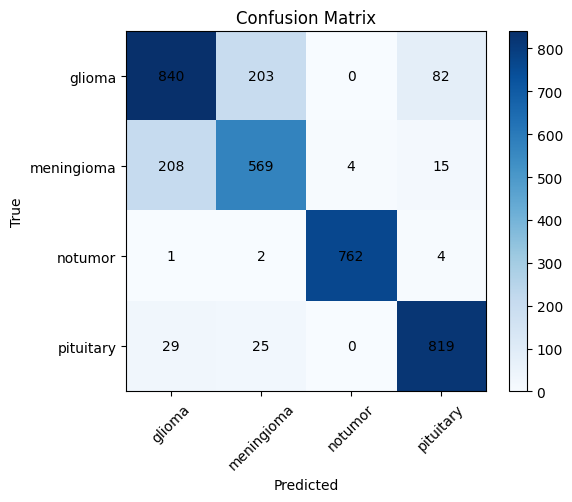

In [14]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        logits = model(images)
        preds = torch.argmax(logits, dim=1).cpu().numpy()

        all_preds.extend(preds.tolist())
        all_labels.extend(labels.numpy().tolist())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

macro_f1 = f1_score(all_labels, all_preds, average="macro")
print(f"Validation Macro F1: {macro_f1:.4f}")
print(classification_report(all_labels, all_preds, target_names=full_train_dataset.classes, digits=4))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks(ticks=np.arange(num_classes), labels=full_train_dataset.classes, rotation=45)
plt.yticks(ticks=np.arange(num_classes), labels=full_train_dataset.classes)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")

plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()